# ML Config — Significant Taxa, Two Platform-Matched Models (PD-vs-HC / AD-vs-HC)

**Why this notebook exists (read before running):** in `ml_02_significant_taxa.ipynb`,
the 3-class HC/PD/AD model showed a study-grouped platform-leakage AUC of 1.000
for shotgun-vs-16S using the significant-taxa feature set, plus a confusion
matrix with **zero** AD<->PD confusion despite heavy AD<->HC and PD<->HC
confusion. That combination is close to a smoking gun: because every PD
sample in this project is shotgun and every AD sample is 16S, "AD vs PD" and
"shotgun vs 16S" are the same question to a classifier - no feature
engineering or scaling fixes that, because it isn't a data-cleaning problem,
it's a study-design one (every study here is single-arm: PD+HC or AD+HC,
never PD+AD).

**The fix implemented here:** stop asking the model to separate AD from PD at
all, since that comparison is structurally unidentifiable from platform.
Instead, fit two independent binary models, each confined to a single
platform by construction:

- **Model A - PD vs HC, shotgun-only** (drops the 16S-only HC samples)
- **Model B - AD vs HC, 16S-only** (drops the shotgun-only HC samples)

Each model can no longer possibly learn "which sequencing platform is this",
because within a model every sample - case and control alike - is on the same
platform. This is a design fix, not a statistical patch: it doesn't reduce
the platform effect, it makes the platform effect a non-question.

**What this trades away:** you no longer get a single number that describes
"how separable are PD, AD, and HC together" - because that number was never
trustworthy in the first place. You get two separately-validated
disease-vs-control models, and you can *qualitatively* compare which taxa
matter for each (Step 8 below) without claiming a formal statistical
comparison between AD and PD biology - that comparison would need studies
that ran both diseases on the same platform, which don't exist in this
dataset.

**Scope note:** this same platform/disease confound is a property of *which
samples exist*, not of which feature block is used - so `ml_01`, `ml_03`,
and `ml_04` almost certainly have the identical structural issue and will
likely need the same two-model treatment before they can be trusted either.
This notebook only converts `ml_02`; treat that as a template for the other
three once the deadline pressure eases enough to redo them.

**Utils change:** `run_loso_evaluation` in `ml_pipeline_utils.py` computed the
pooled AUC with `roc_auc_score(..., multi_class="ovr", ...)`, which sklearn
rejects for a 2-class target. It now branches to a plain binary AUC when
`n_classes == 2`, and is otherwise unchanged - `ml_01`/`ml_03`/`ml_04` are
unaffected. (Also fixed an unrelated latent bug in `run_shap_analysis` that
was causing the Step 9 `AssertionError` in the original `ml_02` notebook -
it built a `get_class_values` helper to handle both old- and new-style SHAP
output shapes, but never actually called it.)

**Keep the updated `ml_pipeline_utils.py` in the same folder as this
notebook.**


In [12]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, run_hyperparameter_search, match_taxon_columns,
    run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

## Step 1 - Load the master feature table and column lists

In [13]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_two_models")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config2_significant_taxa_two_models")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())
print(master.groupby(["disease_group", "platform"]).size())

Master table: (1822, 752)
disease_group
HC    755
PD    751
AD    316
Name: count, dtype: int64
disease_group  platform
AD             16S         316
HC             16S         294
               shotgun     461
PD             shotgun     751
dtype: int64


## Step 2 - Confirm the master table is what you expect

In [14]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")

No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Same as `ml_02`: the ANCOM-BC2-significant genera union (PD-specific +
AD-specific + shared). We keep this shared feature set for both models below
so the comparison in Step 8 is apples-to-apples; if `ml_00` later exports
disease-specific significant-taxa lists, each model could instead use only
its own disease's significant genera - a worthwhile refinement, not done here
to keep this change minimal ahead of the deadline.

In [15]:
feature_cols = significant_taxa_columns
print(f"Using {len(feature_cols)} significant-taxa features.")

Using 43 significant-taxa features.


In [16]:
import pandas as pd

# ---- EDIT THIS: local copies of the ANCOM-BC2 disease-specific outputs ----
# Copy pd_specific_genera.csv and ad_specific_genera.csv from
# /rds/projects/e/elhamsak-pd-thesis/cross_platform/differential_abundance/
# to the same folder as this notebook (or edit the paths below).
PD_SPECIFIC_CSV = Path("pd_specific_genera.csv")
AD_SPECIFIC_CSV = Path("ad_specific_genera.csv")
# -----------------------------------------------------------------------

# Genera significant in BOTH PD-vs-HC and AD-vs-HC (kept in both models so
# Step 8's comparison stays meaningful for at least this subset).
shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium",
               "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]

pd_specific_taxa = pd.read_csv(PD_SPECIFIC_CSV)["taxon"].tolist()
ad_specific_taxa = pd.read_csv(AD_SPECIFIC_CSV)["taxon"].tolist()

shared_cols      = match_taxon_columns(shared_taxa, all_taxa_columns, label="shared taxa")
pd_specific_cols = match_taxon_columns(pd_specific_taxa, all_taxa_columns, label="PD-specific taxa")
ad_specific_cols = match_taxon_columns(ad_specific_taxa, all_taxa_columns, label="AD-specific taxa")

# Each model now gets its OWN disease's significant taxa plus the shared
# ones - not the shared-only intersection used previously. This restores
# what Step 3's "significant-taxa union" was originally meant to give each
# model, just correctly split per disease this time.
pd_feature_cols = sorted(set(shared_cols) | set(pd_specific_cols))
ad_feature_cols = sorted(set(shared_cols) | set(ad_specific_cols))

print(f"Model A (PD vs HC) features: {len(pd_feature_cols)} "
      f"({len(pd_specific_cols)} PD-specific + {len(shared_cols)} shared)")
print(f"Model B (AD vs HC) features: {len(ad_feature_cols)} "
      f"({len(ad_specific_cols)} AD-specific + {len(shared_cols)} shared)")


Model A (PD vs HC) features: 38 (31 PD-specific + 7 shared)
Model B (AD vs HC) features: 19 (12 AD-specific + 7 shared)


## Step 4 - Split into two platform-matched subsets (replaces the platform-leakage diagnostic)

This is the actual fix. Each subset below is restricted to a single
platform, so within either model there is no shotgun/16S axis left for the
classifier to find - "which platform" and "which class" are no longer
confounded because platform is now constant within each model.

- **Model A (shotgun-only): PD vs HC** - drops the 16S-only HC samples.
- **Model B (16S-only): AD vs HC** - drops the shotgun-only HC samples.

The assertions below aren't decorative - they're the thing that actually
proves the fix worked: `platform.nunique() == 1` in each subset means the
confound is gone by construction, not by hope.

In [17]:
pd_df = master[(master["disease_group"].isin(["PD", "HC"])) &
               (master["platform"] == "shotgun")].reset_index(drop=True)
ad_df = master[(master["disease_group"].isin(["AD", "HC"])) &
               (master["platform"] == "16S")].reset_index(drop=True)

assert pd_df["platform"].nunique() == 1, "PD/HC subset should be single-platform (shotgun) - it isn't"
assert ad_df["platform"].nunique() == 1, "AD/HC subset should be single-platform (16S) - it isn't"

print("Model A - PD vs HC (shotgun-only):")
print(pd_df["disease_group"].value_counts(), "\n")

print("Model B - AD vs HC (16S-only):")
print(ad_df["disease_group"].value_counts())

# Sanity check: confirm we haven't silently dropped every HC sample from
# either subset (would happen if the platform column values don't match
# "shotgun"/"16S" exactly - fail loudly instead of training on an empty class)
assert pd_df["disease_group"].value_counts().min() > 0, "One class is empty in the PD/HC subset - check platform label spelling"
assert ad_df["disease_group"].value_counts().min() > 0, "One class is empty in the AD/HC subset - check platform label spelling"

Model A - PD vs HC (shotgun-only):
disease_group
PD    751
HC    461
Name: count, dtype: int64 

Model B - AD vs HC (16S-only):
disease_group
AD    316
HC    294
Name: count, dtype: int64


## Step 5 - One function, run twice

Steps 5-10 of the original `ml_02` (encode labels, scale, tune, LOSO-evaluate,
confusion matrix, SHAP, save artifacts) are identical in shape for both
models - only the input subset and an output subfolder differ. Wrapping that
in one function keeps the two runs from drifting apart the way copy-pasted
notebook cells tend to.

`n_splits` for the inner hyperparameter search is capped at the smaller
class's study count (never below 2), since `StratifiedGroupKFold` needs at
least that many groups per class - the same guard `check_platform_leakage`
already uses elsewhere in this pipeline.

In [18]:
def run_one_model(df, feature_cols, model_label, output_subdir):
    print(f"\n{'='*70}\nRunning model: {model_label}\n{'='*70}")
    sub_output_dir = OUTPUT_DIR / output_subdir
    sub_output_dir.mkdir(parents=True, exist_ok=True)

    label_encoder = LabelEncoder()
    df = df.copy()
    df["y"] = label_encoder.fit_transform(df["disease_group"])
    print("Class encoding:", dict(zip(label_encoder.classes_,
                                       label_encoder.transform(label_encoder.classes_))))

    X = df[feature_cols].values
    y = df["y"].values
    groups = df["study_id"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"Final feature count: {len(feature_cols)}")

    # Cap the inner CV split count at the smaller class's study count.
    n_studies_per_class = df.groupby("disease_group")["study_id"].nunique()
    n_splits = max(2, min(5, int(n_studies_per_class.min())))
    if n_splits < 5:
        print(f"NOTE: reduced inner CV n_splits to {n_splits} "
              f"(smaller class has only {int(n_studies_per_class.min())} studies).")

    grid = run_hyperparameter_search(X_scaled, y, groups, n_splits=n_splits)

    loso_df, all_y_true, all_y_pred, all_y_proba = run_loso_evaluation(
        X_scaled, y, groups, grid.best_params_, label_encoder, sub_output_dir
    )
    all_y_proba_stacked = np.vstack(all_y_proba)[:, 1]  # positive-class probability, flattened across folds

    cm_df = plot_confusion_matrix(all_y_true, all_y_pred, label_encoder, sub_output_dir)

    final_model = RandomForestClassifier(**grid.best_params_, class_weight="balanced",
                                          random_state=RANDOM_STATE, n_jobs=-1)
    final_model.fit(X_scaled, y)

    shap_values = run_shap_analysis(final_model, X_scaled, feature_cols, label_encoder,
                                     sub_output_dir, max_display=30 if len(feature_cols) > 40 else None)

    save_artifacts(final_model, scaler, label_encoder, feature_cols, sub_output_dir)

    return {
        "model_label": model_label,
        "label_encoder": label_encoder,
        "final_model": final_model,
        "grid": grid,
        "loso_df": loso_df,
        "y_true": all_y_true,
        "y_proba": all_y_proba_stacked,   # add this
        "cm_df": cm_df,
        "shap_values": shap_values,
    }

## Step 6 - Model A: PD vs HC (shotgun-only)


Running model: PD vs HC (shotgun-only, PD-specific+shared taxa)
Class encoding: {'HC': np.int64(0), 'PD': np.int64(1)}
Final feature count: 38
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV f1_macro: 0.6899203448459895
Fold 0 (held out bedarf2017): n=59, classes_present=2/2, F1_macro=0.542
Fold 1 (held out boktor2023_rumc): n=113, classes_present=2/2, F1_macro=0.805
Fold 2 (held out boktor2023_tbc): n=112, classes_present=2/2, F1_macro=0.838
Fold 3 (held out clasen2024): n=126, classes_present=2/2, F1_macro=0.731
Fold 4 (held out mao2021): n=78, classes_present=2/2, F1_macro=0.438
Fold 5 (held out wallen2022): n=724, classes_present=2/2, F1_macro=0.550

--- LOSO summary (pooled out-of-fold predictions across all folds) ---
Pooled AUC (binary): 0.680
Pooled F1_macro: 0.631
(Per-fold F1_macro, reference only, many folds missing a class by design: 0.651 +/- 0.163)
     HC   PD
HC  329  13

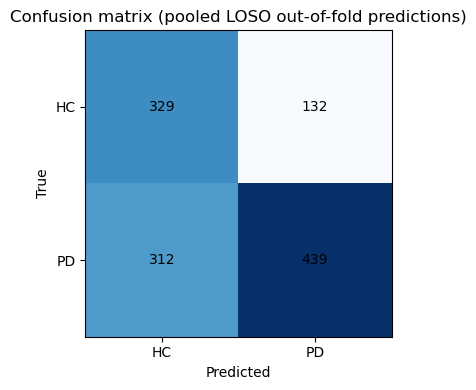

              precision    recall  f1-score   support

          HC       0.51      0.71      0.60       461
          PD       0.77      0.58      0.66       751

    accuracy                           0.63      1212
   macro avg       0.64      0.65      0.63      1212
weighted avg       0.67      0.63      0.64      1212

Generating SHAP beeswarm for class: HC


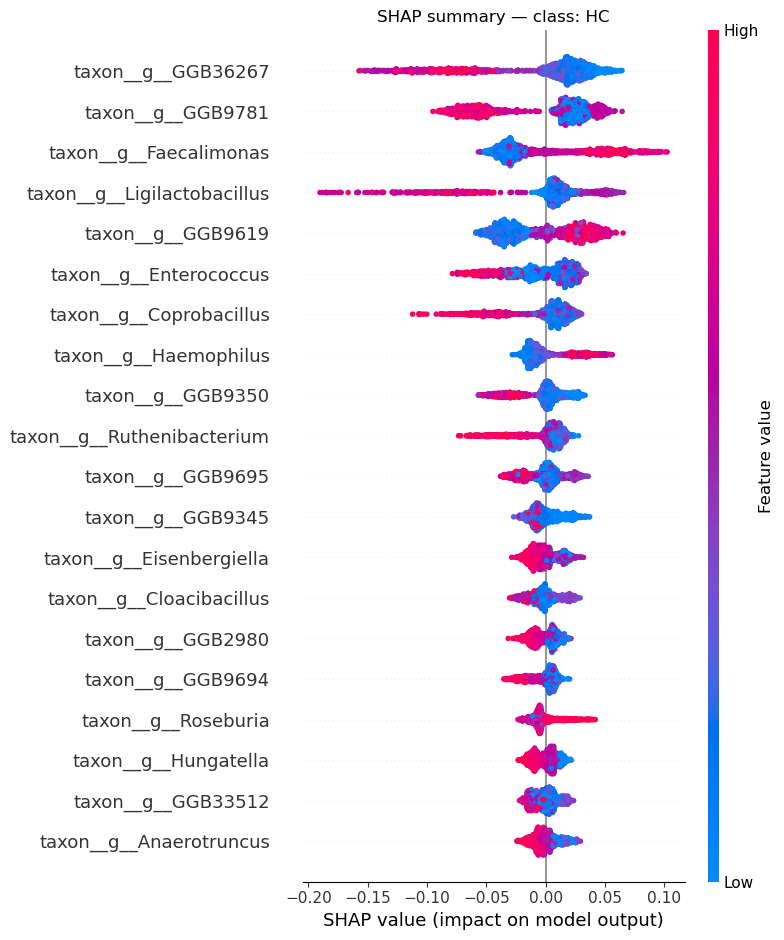

Generating SHAP beeswarm for class: PD


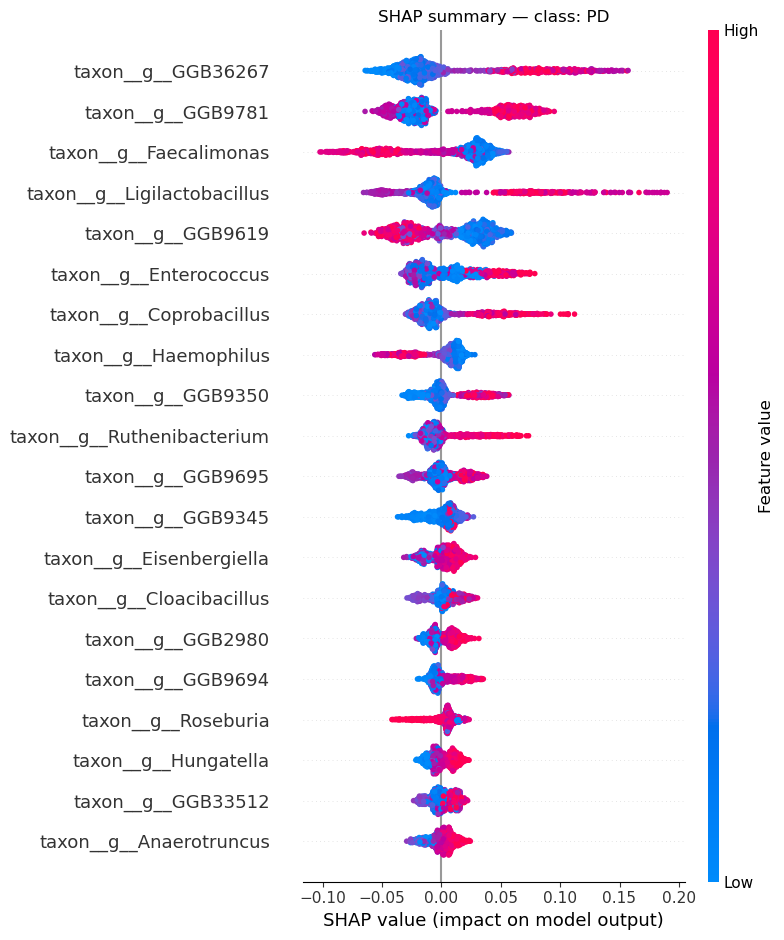

Saved model, scaler, label encoder, and feature list to: ml_config2_significant_taxa_two_models\pd_vs_hc_shotgun


<Figure size 640x480 with 0 Axes>

In [19]:
pd_results = run_one_model(pd_df, pd_feature_cols, "PD vs HC (shotgun-only, PD-specific+shared taxa)", "pd_vs_hc_shotgun")


## Step 7 - Model B: AD vs HC (16S-only)


Running model: AD vs HC (16S-only, AD-specific+shared taxa)
Class encoding: {'AD': np.int64(0), 'HC': np.int64(1)}
Final feature count: 19
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 500}
Best CV f1_macro: 0.5964527315144215
Fold 0 (held out binyinli2019): n=60, classes_present=2/2, F1_macro=0.630
Fold 1 (held out cirstea2022): n=98, classes_present=2/2, F1_macro=0.680
Fold 2 (held out ling2021): n=171, classes_present=2/2, F1_macro=0.528
Fold 3 (held out liu2019): n=61, classes_present=2/2, F1_macro=0.574
Fold 4 (held out yamashiro2024): n=37, classes_present=2/2, F1_macro=0.607
Fold 5 (held out yildirim2022): n=97, classes_present=2/2, F1_macro=0.601
Fold 6 (held out zhuang2018): n=86, classes_present=2/2, F1_macro=0.580

--- LOSO summary (pooled out-of-fold predictions across all folds) ---
Pooled AUC (binary): 0.642
Pooled F1_macro: 0.622
(Per-fold F1_macro, reference only, many folds missing 

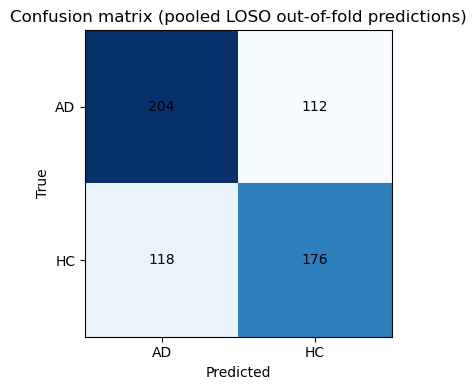

              precision    recall  f1-score   support

          AD       0.63      0.65      0.64       316
          HC       0.61      0.60      0.60       294

    accuracy                           0.62       610
   macro avg       0.62      0.62      0.62       610
weighted avg       0.62      0.62      0.62       610

Generating SHAP beeswarm for class: AD


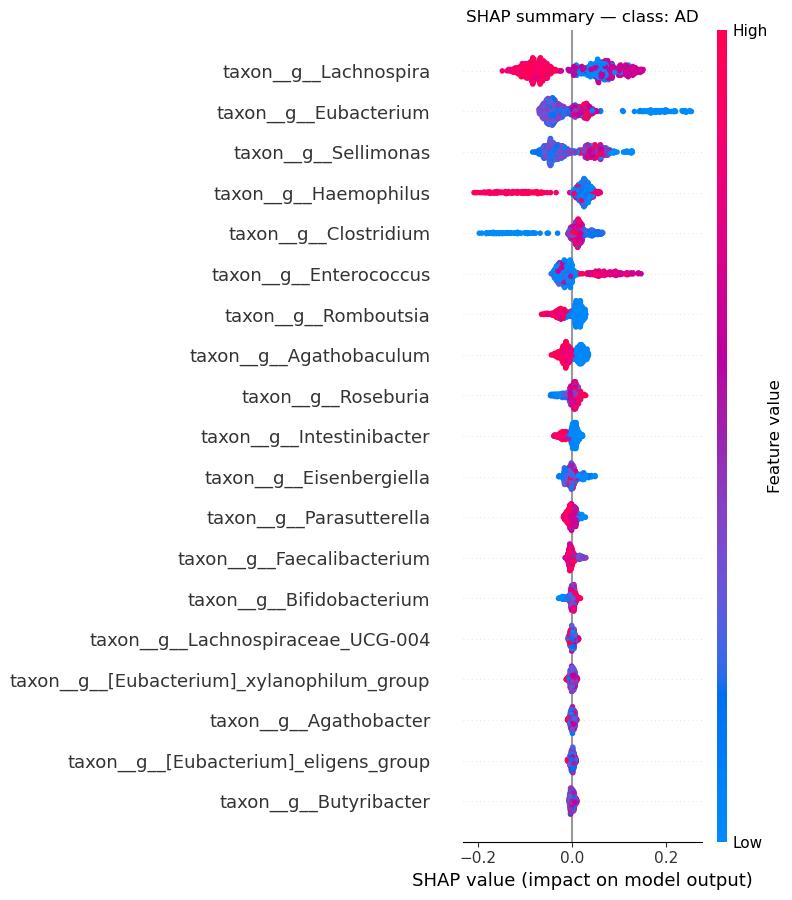

Generating SHAP beeswarm for class: HC


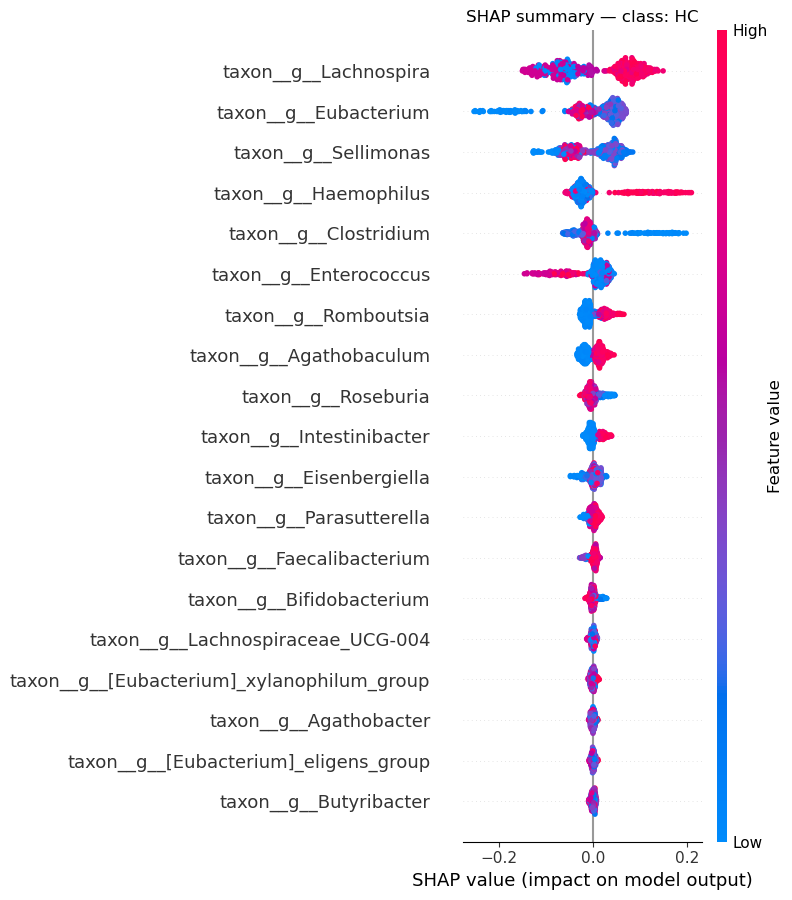

Saved model, scaler, label encoder, and feature list to: ml_config2_significant_taxa_two_models\ad_vs_hc_16s


<Figure size 640x480 with 0 Axes>

In [20]:
ad_results = run_one_model(ad_df, ad_feature_cols, "AD vs HC (16S-only, AD-specific+shared taxa)", "ad_vs_hc_16s")


## Step 8 - Compare the two models' top taxa (qualitative, not a statistical test)

This is *not* a formal AD-vs-PD comparison - that comparison would need
studies running both diseases on the same platform, which don't exist here.
What this table gives you is a side-by-side of which significant genera each
disease-vs-HC model actually leaned on (Gini importance from each model's
final RF, plus which model each genus ranks higher in). Useful for a
"shared vs distinct candidate taxa" discussion in the thesis, framed
explicitly as suggestive rather than confirmatory given the platforms
differ.

In [21]:
import numpy as np

pd_importances = pd.Series(pd_results["final_model"].feature_importances_,
                            index=pd_feature_cols, name="importance_PD_vs_HC")
ad_importances = pd.Series(ad_results["final_model"].feature_importances_,
                            index=ad_feature_cols, name="importance_AD_vs_HC")

# outer join on genus name - PD-specific genera get NaN in the AD column
# and vice versa, since they were never features in that model
comparison_df = pd.concat([pd_importances, ad_importances], axis=1)

comparison_df["gene_set"] = np.select(
    [comparison_df.index.isin(shared_cols),
     comparison_df.index.isin(pd_specific_cols),
     comparison_df.index.isin(ad_specific_cols)],
    ["shared", "PD-specific", "AD-specific"],
    default="unknown"
)

comparison_df["rank_PD_vs_HC"] = comparison_df["importance_PD_vs_HC"].rank(ascending=False)
comparison_df["rank_AD_vs_HC"] = comparison_df["importance_AD_vs_HC"].rank(ascending=False)

# "higher_ranked_in" is only a meaningful comparison for genera present in
# BOTH models (the shared set) - for PD-specific/AD-specific genera there is
# nothing to compare against, so leave it blank rather than implying a
# comparison that can't actually be made.
comparison_df["higher_ranked_in"] = np.nan
shared_mask = comparison_df["gene_set"] == "shared"
comparison_df.loc[shared_mask, "higher_ranked_in"] = np.where(
    comparison_df.loc[shared_mask, "rank_PD_vs_HC"] < comparison_df.loc[shared_mask, "rank_AD_vs_HC"],
    "PD_vs_HC", "AD_vs_HC"
)

comparison_df = comparison_df.sort_values(
    ["importance_PD_vs_HC", "importance_AD_vs_HC"], ascending=False, na_position="last"
)

comparison_df.to_csv(OUTPUT_DIR / "feature_importance_comparison.csv")
comparison_df.head(20)


C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_37756\3821370957.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['AD_vs_HC' 'AD_vs_HC' 'PD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC'
 'AD_vs_HC']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison_df.loc[shared_mask, "higher_ranked_in"] = np.where(


,importance_PD_vs_HC,importance_AD_vs_HC,gene_set,rank_PD_vs_HC,rank_AD_vs_HC,higher_ranked_in
taxon__g__Ligilactobacillus,0.072975,NaN,PD-specific,1.0,NaN,NaN
taxon__g__GGB36267,0.070751,NaN,PD-specific,2.0,NaN,NaN
taxon__g__GGB9781,0.066972,NaN,PD-specific,3.0,NaN,NaN
taxon__g__Faecalimonas,0.053893,NaN,PD-specific,4.0,NaN,NaN
taxon__g__Enterococcus,0.052226,0.072454,shared,5.0,6.0,PD_vs_HC
taxon__g__GGB9619,0.047154,NaN,PD-specific,6.0,NaN,NaN
taxon__g__Coprobacillus,0.046888,NaN,PD-specific,7.0,NaN,NaN
taxon__g__GGB9350,0.032242,NaN,PD-specific,8.0,NaN,NaN
taxon__g__GGB9695,0.031470,NaN,PD-specific,9.0,NaN,NaN
taxon__g__Ruthenibacterium,0.031324,NaN,PD-specific,10.0,NaN,NaN


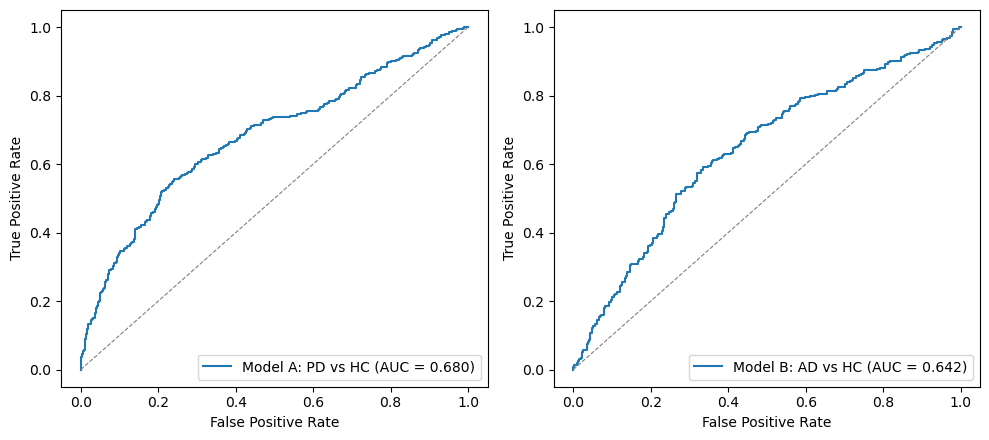

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y_true, y_proba, model_label, ax):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_label} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_roc(pd_results["y_true"], pd_results["y_proba"], "Model A: PD vs HC", axes[0])
plot_roc(ad_results["y_true"], ad_results["y_proba"], "Model B: AD vs HC", axes[1])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_both_models.png", dpi=300)

## Notes for the Methods/limitations section

- The original `ml_02` 3-class HC/PD/AD model is superseded by these two
  binary models for reporting purposes: its AD-vs-PD boundary was shown to be
  structurally confounded with sequencing platform (study-grouped platform
  AUC of 1.000; zero AD<->PD confusion, heavy AD/PD<->HC confusion), and no
  feature or scaling choice can separate platform from disease group on that
  axis because every PD study is shotgun and every AD study is 16S.
- Each model here (PD vs HC shotgun-only; AD vs HC 16S-only) is single-platform
  by construction, so it cannot learn platform as a proxy for the label - the
  `platform.nunique() == 1` assertions in Step 4 are the evidence for this,
  not just a comment.
- The Step 8 feature-importance comparison is descriptive only. Do not
  present it as a statistical AD-vs-PD contrast - frame any shared-taxa
  observations as hypothesis-generating, since a platform confound between
  the two disease groups still exists at the *comparison* level even though
  it no longer exists *within* either individual model.
- Consider applying this same platform-matched two-model split to `ml_01`
  (all taxa), `ml_03` (+clinical), and `ml_04` (+pathway) if time allows -
  they share the identical sample-level confound regardless of feature block.